In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
import pandas as pd
from dotenv import load_dotenv, find_dotenv
from sqlalchemy import create_engine

In [ ]:
# подгружаем .env
load_dotenv()

In [ ]:
# Считываем все креды
src_host = os.environ.get('DB_SOURCE_HOST')
src_port = os.environ.get('DB_SOURCE_PORT')
src_username = os.environ.get('DB_SOURCE_USER')
src_password = os.environ.get('DB_SOURCE_PASSWORD')
src_db = os.environ.get('DB_SOURCE_NAME')

dst_host = os.environ.get('DB_DESTINATION_HOST')
dst_port = os.environ.get('DB_DESTINATION_PORT')
dst_username = os.environ.get('DB_DESTINATION_USER')
dst_password = os.environ.get('DB_DESTINATION_PASSWORD')
dst_db = os.environ.get('DB_DESTINATION_NAME')

s3_bucket = os.environ.get('S3_BUCKET_NAME')
s3_access_key = os.environ.get('AWS_ACCESS_KEY_ID')
s3_secret_access_key = os.environ.get('AWS_SECRET_ACCESS_KEY')

In [ ]:
# Создадим соединения
# src_conn = create_engine(f'postgresql://{src_username}:{src_password}@{src_host}:{src_port}/{src_db}')
dst_conn = create_engine(f'postgresql://{dst_username}:{dst_password}@{dst_host}:{dst_port}/{dst_db}')

**Сбор данных**

In [2]:
data = pd.read_sql("""
select
    b.build_year, b.building_type_int, b.latitude, b.longitude, b.ceiling_height, b.flats_count, b.floors_total, b.has_elevator,
    f.floor, f.kitchen_area, f.living_area, f.rooms, f.is_apartment, f.studio, f.total_area, f.price
from buildings as b
inner join flats as f on b.id = f.building_id""", dst_conn)
data.head()

,build_year,building_type_int,latitude,longitude,ceiling_height,flats_count,floors_total,has_elevator,floor,kitchen_area,living_area,rooms,is_apartment,studio,total_area,price
0,1965,6,55.717113,37.781120,2.64,84,12,True,9,9.9,19.900000,1,False,False,35.099998,9500000
1,2001,2,55.794849,37.608013,3.00,97,10,True,7,0.0,16.600000,1,False,False,43.000000,13500000
2,2000,4,55.740040,37.761742,2.70,80,10,True,9,9.0,32.000000,2,False,False,56.000000,13500000
3,2002,4,55.672016,37.570877,2.64,771,17,True,1,10.1,43.099998,3,False,False,76.000000,20000000
4,1971,1,55.808807,37.707306,2.60,208,9,True,3,3.0,14.000000,1,False,False,24.000000,5200000


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141362 entries, 0 to 141361
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   build_year         141362 non-null  int64  
 1   building_type_int  141362 non-null  int64  
 2   latitude           141362 non-null  float64
 3   longitude          141362 non-null  float64
 4   ceiling_height     141362 non-null  float64
 5   flats_count        141362 non-null  int64  
 6   floors_total       141362 non-null  int64  
 7   has_elevator       141362 non-null  bool   
 8   floor              141362 non-null  int64  
 9   kitchen_area       141362 non-null  float64
 10  living_area        141362 non-null  float64
 11  rooms              141362 non-null  int64  
 12  is_apartment       141362 non-null  bool   
 13  studio             141362 non-null  bool   
 14  total_area         141362 non-null  float64
 15  price              141362 non-null  int64  
dtypes:

**EDA**

In [17]:
data = pd.read_sql("""
select * from real_estate_raw
""", dst_conn)
data.head()

,id,flat_id,building_id,build_year,building_type_int,latitude,longitude,ceiling_height,flats_count,floors_total,has_elevator,floor,kitchen_area,living_area,rooms,is_apartment,studio,total_area,price
0,1,0,6220,1965,6,55.717113,37.781120,2.64,84,12,1,9,9.9,19.900000,1,0,0,35.099998,9500000
1,2,1,18012,2001,2,55.794849,37.608013,3.00,97,10,1,7,0.0,16.600000,1,0,0,43.000000,13500000
2,3,2,17821,2000,4,55.740040,37.761742,2.70,80,10,1,9,9.0,32.000000,2,0,0,56.000000,13500000
3,4,3,18579,2002,4,55.672016,37.570877,2.64,771,17,1,1,10.1,43.099998,3,0,0,76.000000,20000000
4,5,4,9293,1971,1,55.808807,37.707306,2.60,208,9,1,3,3.0,14.000000,1,0,0,24.000000,5200000


In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141362 entries, 0 to 141361
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 141362 non-null  int64  
 1   flat_id            141362 non-null  int64  
 2   building_id        141362 non-null  int64  
 3   build_year         141362 non-null  int64  
 4   building_type_int  141362 non-null  int64  
 5   latitude           141362 non-null  float64
 6   longitude          141362 non-null  float64
 7   ceiling_height     141362 non-null  float64
 8   flats_count        141362 non-null  int64  
 9   floors_total       141362 non-null  int64  
 10  has_elevator       141362 non-null  int64  
 11  floor              141362 non-null  int64  
 12  kitchen_area       141362 non-null  float64
 13  living_area        141362 non-null  float64
 14  rooms              141362 non-null  int64  
 15  is_apartment       141362 non-null  int64  
 16  st

In [7]:
data.describe()

,id,flat_id,building_id,build_year,building_type_int,latitude,longitude,ceiling_height,flats_count,floors_total,has_elevator,floor,kitchen_area,living_area,rooms,is_apartment,studio,total_area,price
count,141362.000000,141362.000000,141362.000000,141362.000000,141362.000000,141362.000000,141362.000000,141362.000000,141362.000000,141362.000000,141362.000000,141362.000000,141362.000000,141362.000000,141362.000000,141362.000000,141362.0,141362.000000,1.413620e+05
mean,70681.500000,70680.500000,14053.665235,1986.600048,3.232941,55.730059,37.589235,2.753650,251.993230,14.107554,0.897384,7.467346,9.001579,31.056948,2.129476,0.009706,0.0,62.374644,1.944162e+07
std,40807.838714,40807.838714,6988.831066,22.136409,1.459461,0.102611,0.150122,0.223275,207.336169,6.898045,0.303458,5.717144,5.264076,23.968640,0.994340,0.098038,0.0,40.295864,6.626954e+07
min,1.000000,0.000000,1.000000,1901.000000,0.000000,55.211460,36.864372,2.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.0,11.000000,1.100000e+01
25%,35341.250000,35340.250000,8535.250000,1969.000000,2.000000,55.653858,37.491764,2.640000,111.000000,9.000000,1.000000,3.000000,6.100000,19.000000,1.000000,0.000000,0.0,39.299999,8.900000e+06
50%,70681.500000,70680.500000,14332.000000,1985.000000,4.000000,55.724686,37.581146,2.640000,200.000000,14.000000,1.000000,6.000000,8.800000,29.400000,2.000000,0.000000,0.0,53.000000,1.185000e+07
75%,106021.750000,106020.750000,20475.000000,2007.000000,4.000000,55.807323,37.691055,2.800000,324.000000,17.000000,1.000000,10.000000,10.200000,41.400002,3.000000,0.000000,0.0,72.000000,1.695000e+07
max,141362.000000,141361.000000,24620.000000,2023.000000,6.000000,56.011032,37.946411,27.000000,4455.000000,99.000000,1.000000,56.000000,203.000000,700.000000,20.000000,1.000000,0.0,960.299988,9.873738e+09


In [8]:
data.shape

(141362, 19)

In [10]:
data.drop(columns=['id', 'flat_id', 'building_id']).duplicated().sum()

np.int64(9116)

Датасет состоит из 141 362 наблюдений и 19 колонок (int64, float64). Пропущенные значения (Null) полностью отсутствуют. Есть дубли по строкам. Колонку 'building_id' можно удалить, 'flat_id' оставить для идентификации строк.

In [11]:
target = 'price'
num_features = ['build_year', 'latitude', 'longitude', 'ceiling_height', 'flats_count', 'floors_total', 'floor', 'kitchen_area', 'living_area', 'rooms', 'total_area']
cat_features = ['building_type_int']
cat_bin_features = ['has_elevator', 'is_apartment', 'studio']


В датасете 11 числовых переменных, 1 категориальная и 3 бинарных. Целевая переменная price.

<Axes: xlabel='building_type_int', ylabel='count'>

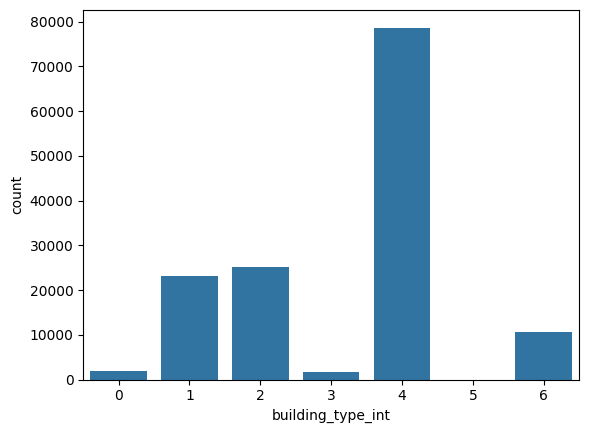

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(data=data, x=cat_features[0])

Исследуем числовые переменные в разрезе building_type_int

/tmp/ipykernel_2147/3771244185.py:26: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


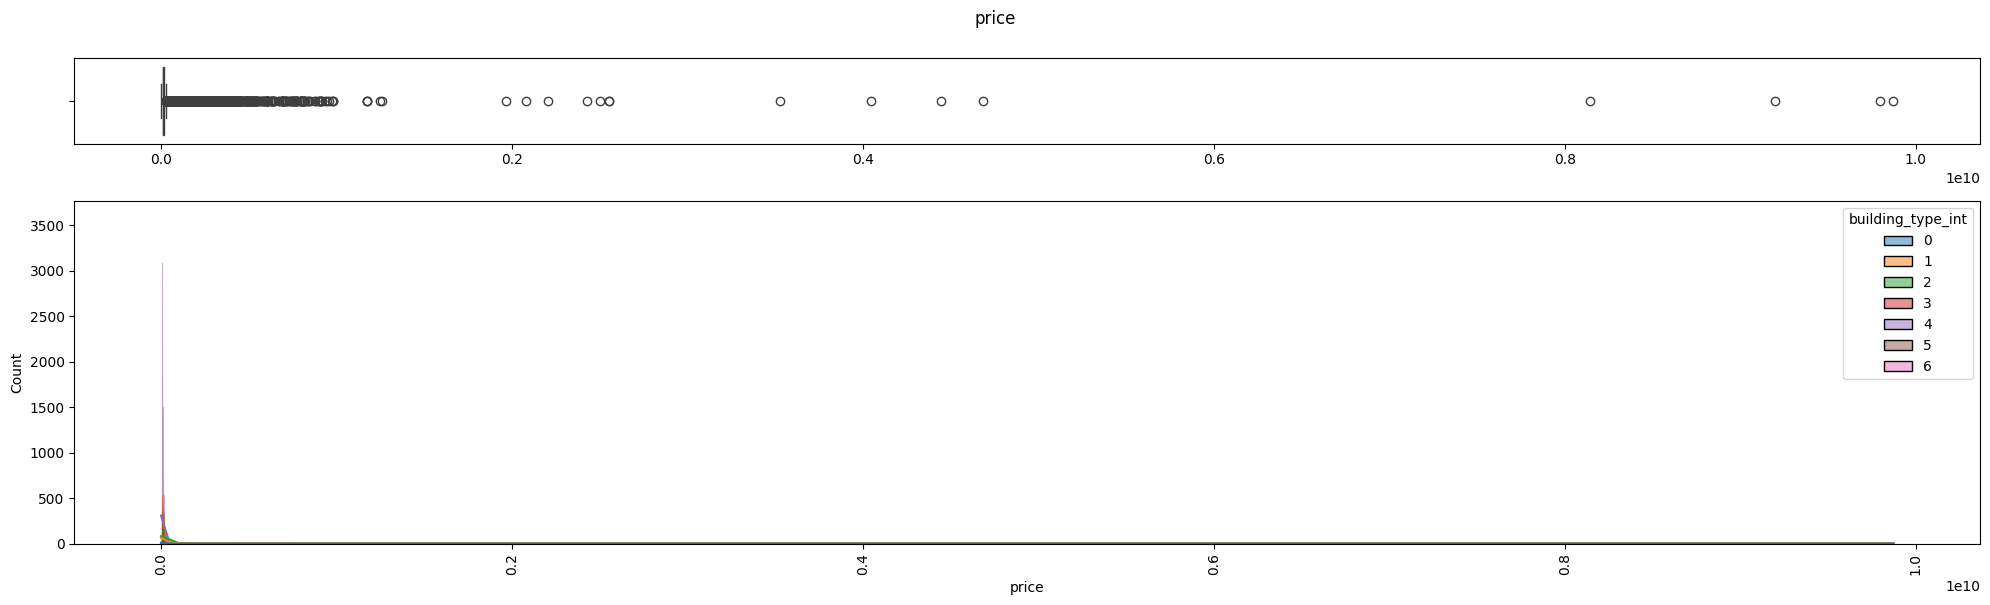

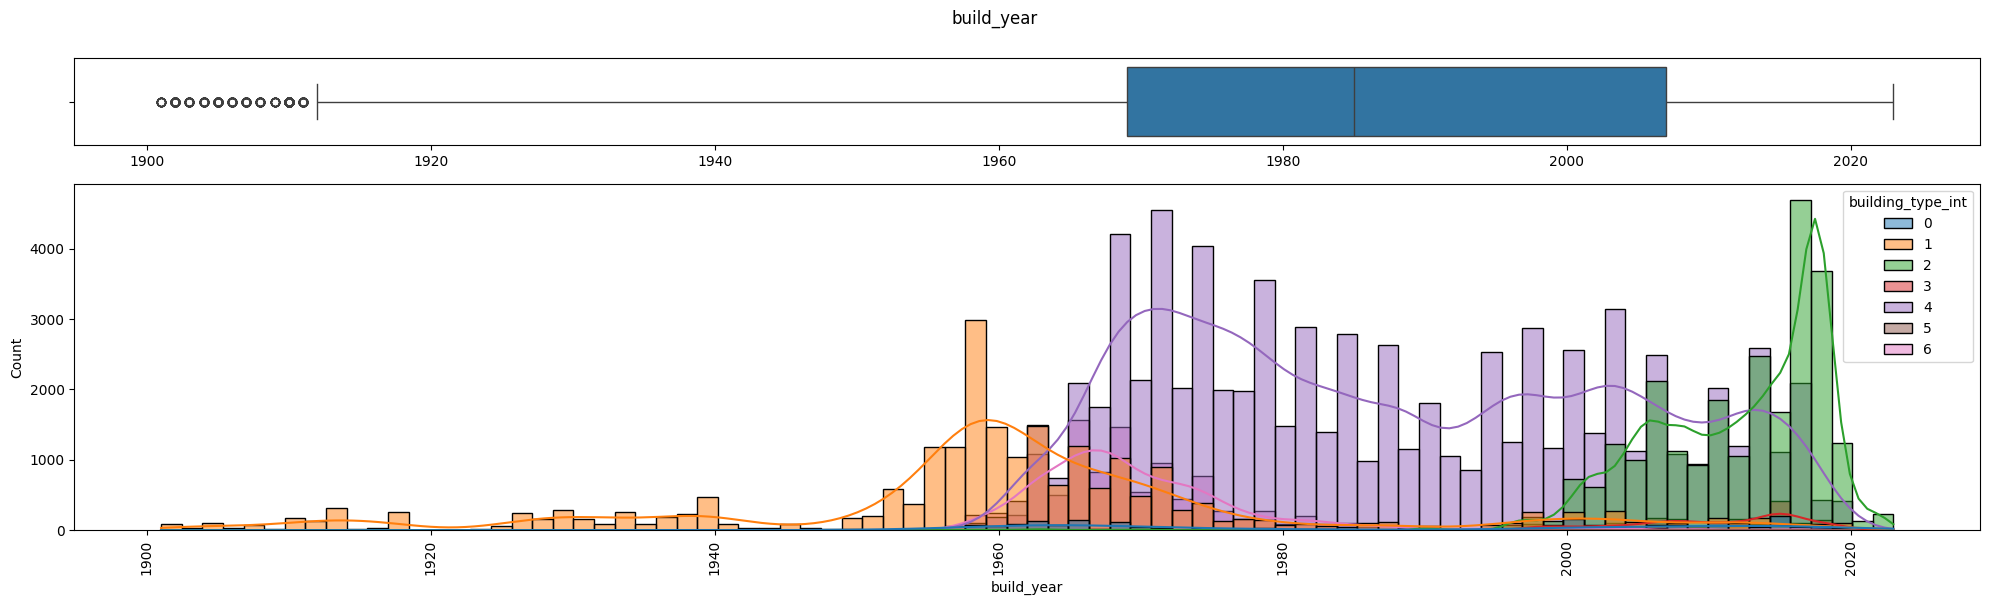

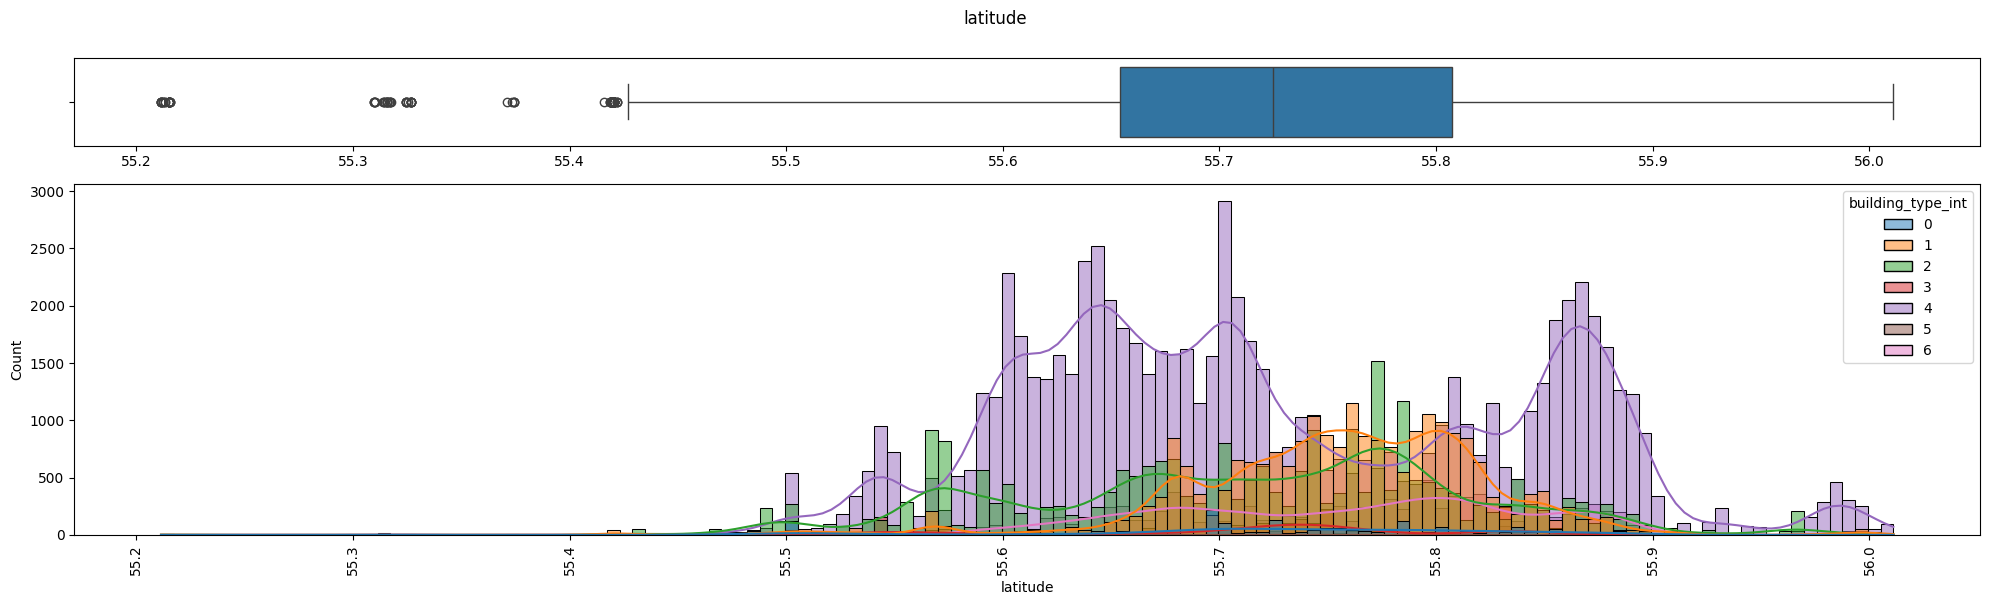

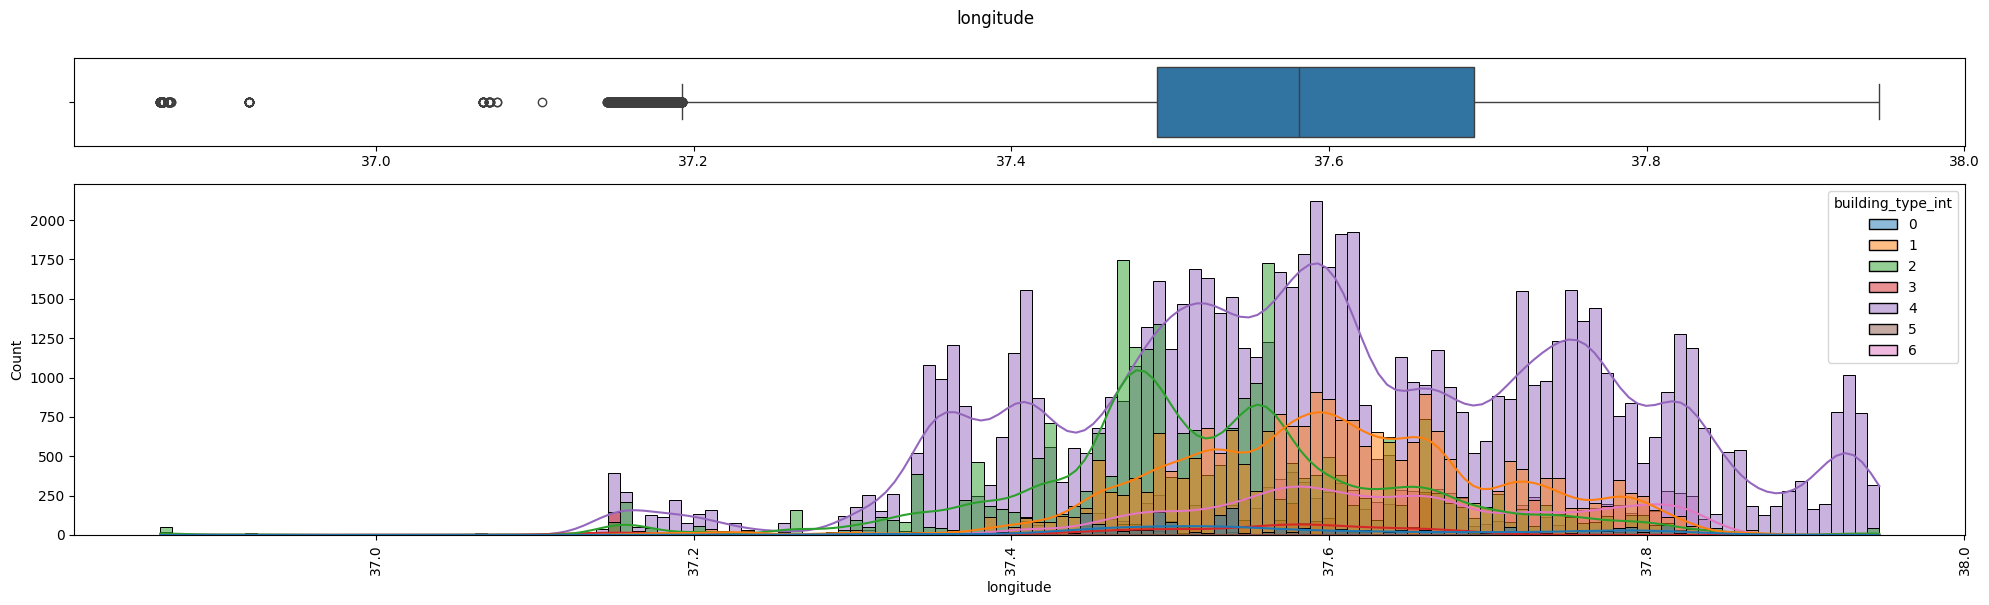

/tmp/ipykernel_2147/3771244185.py:26: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


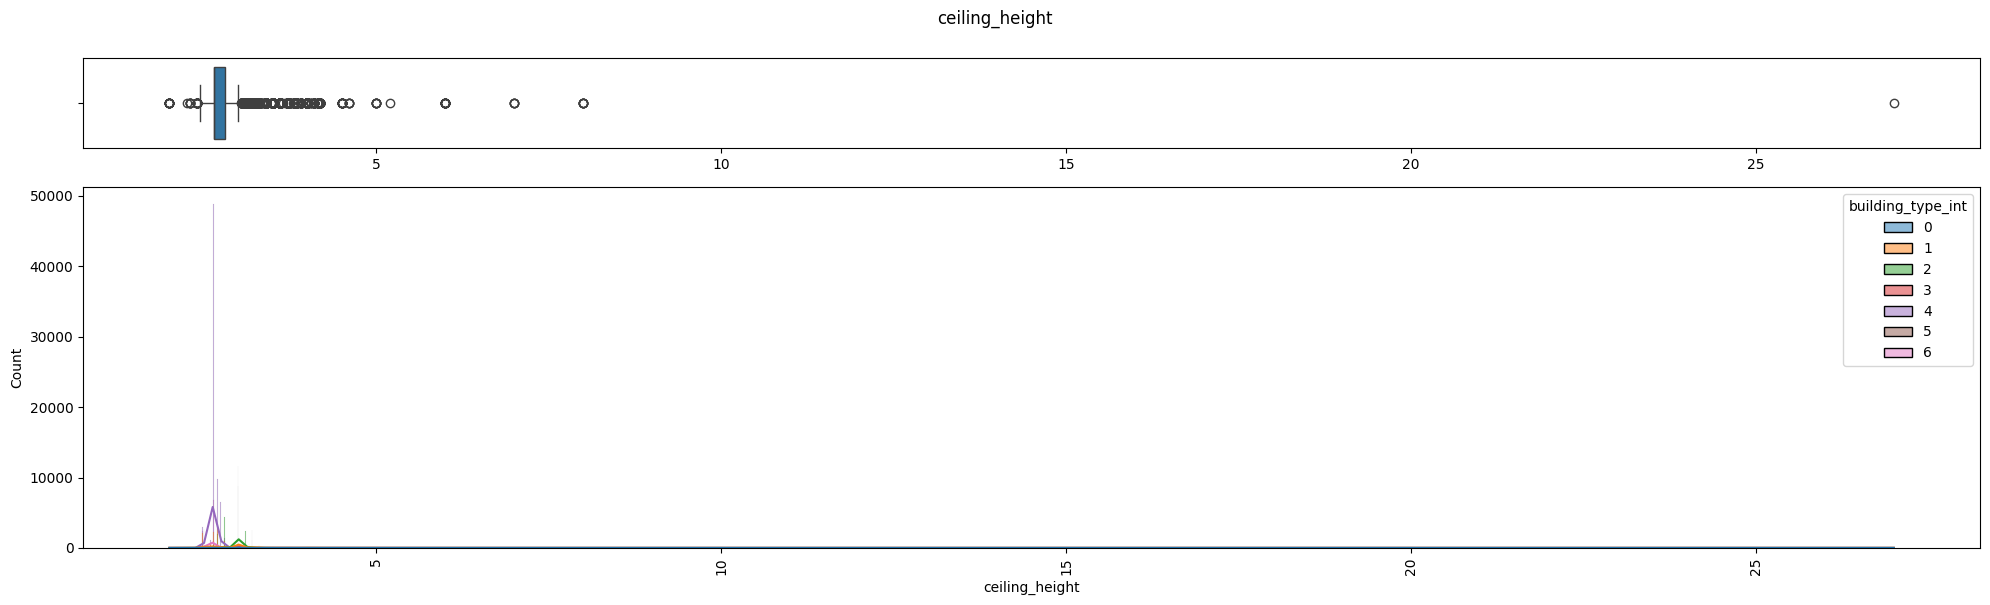

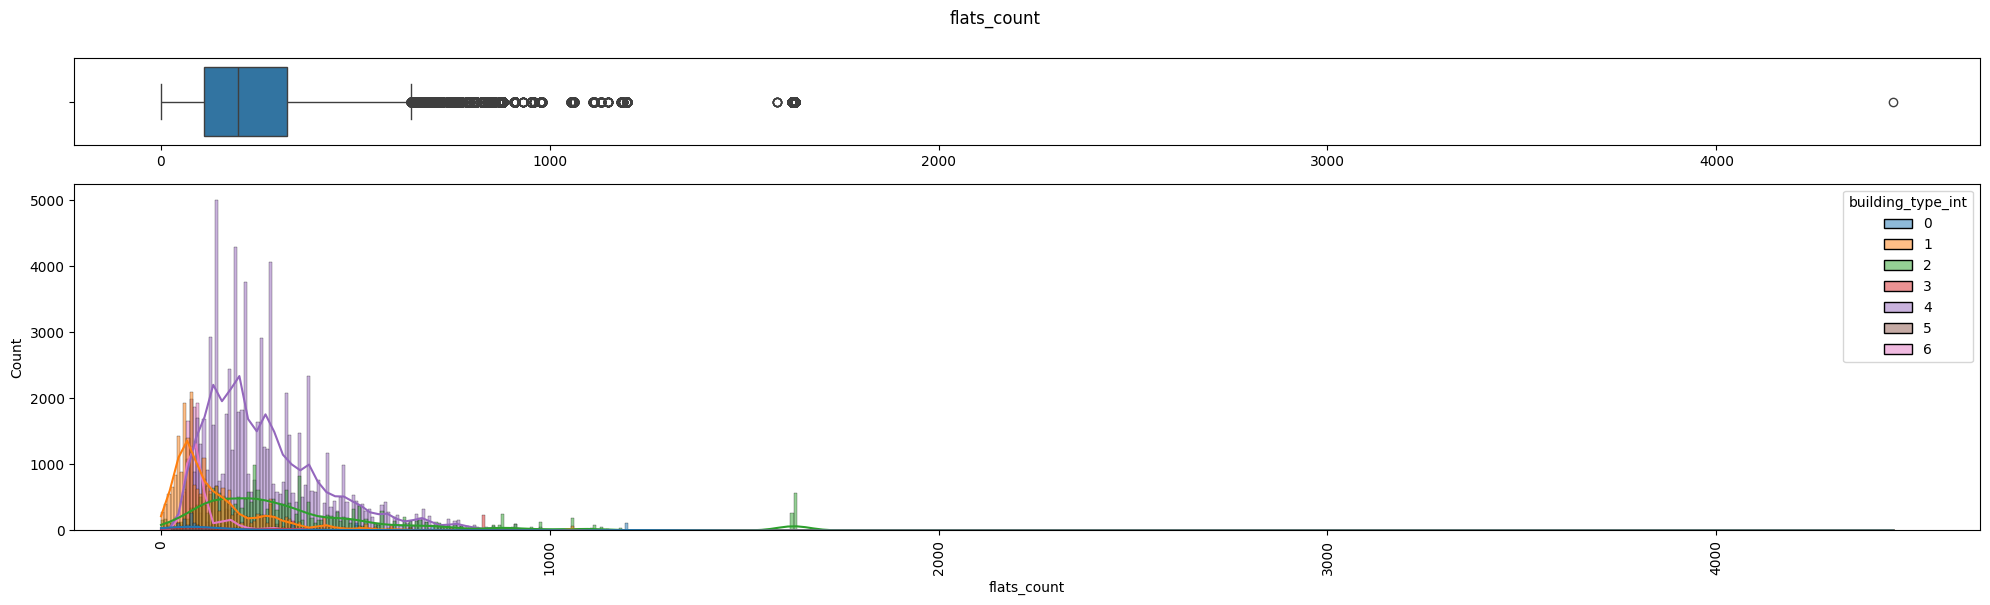

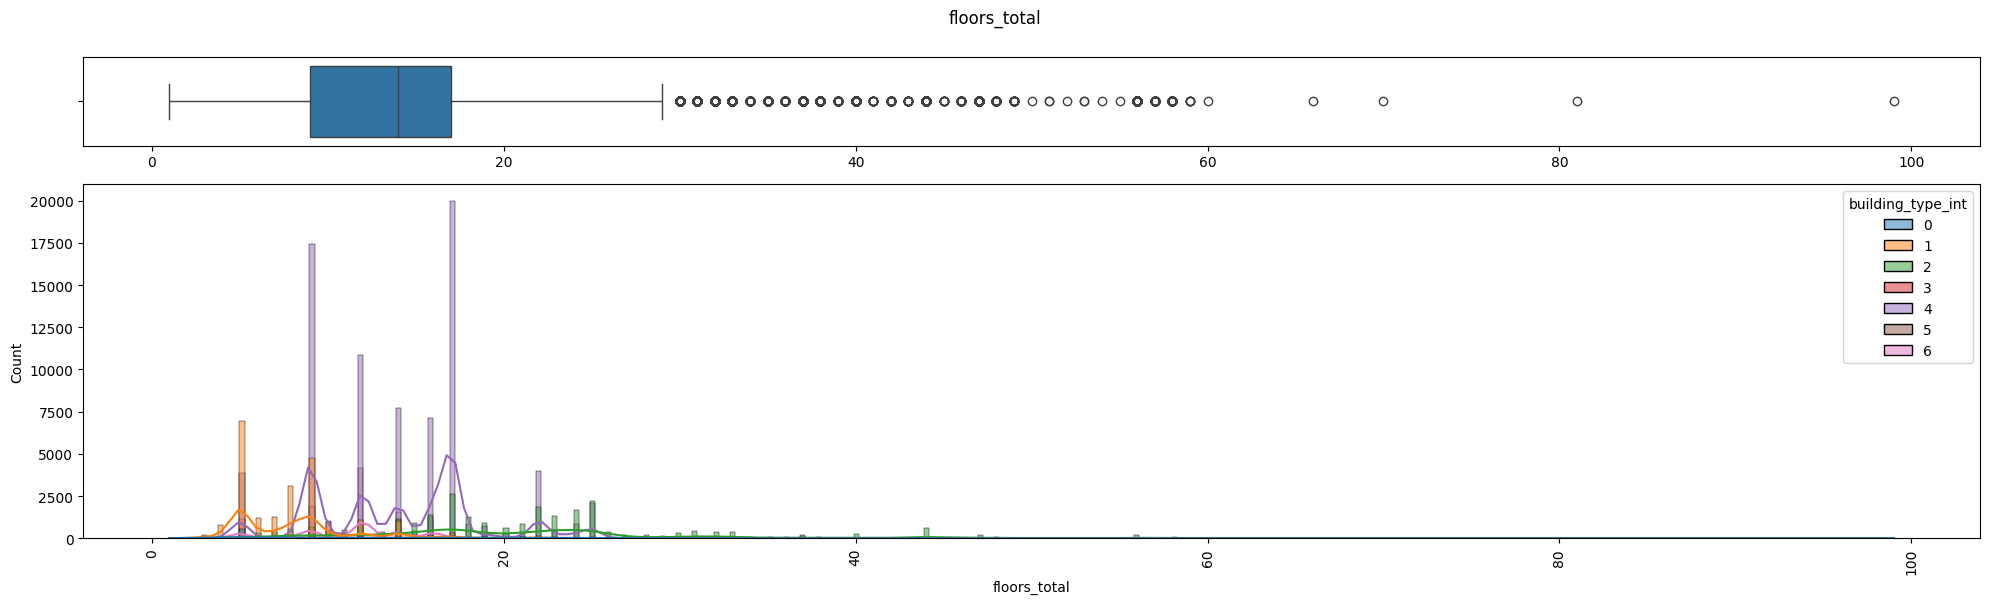

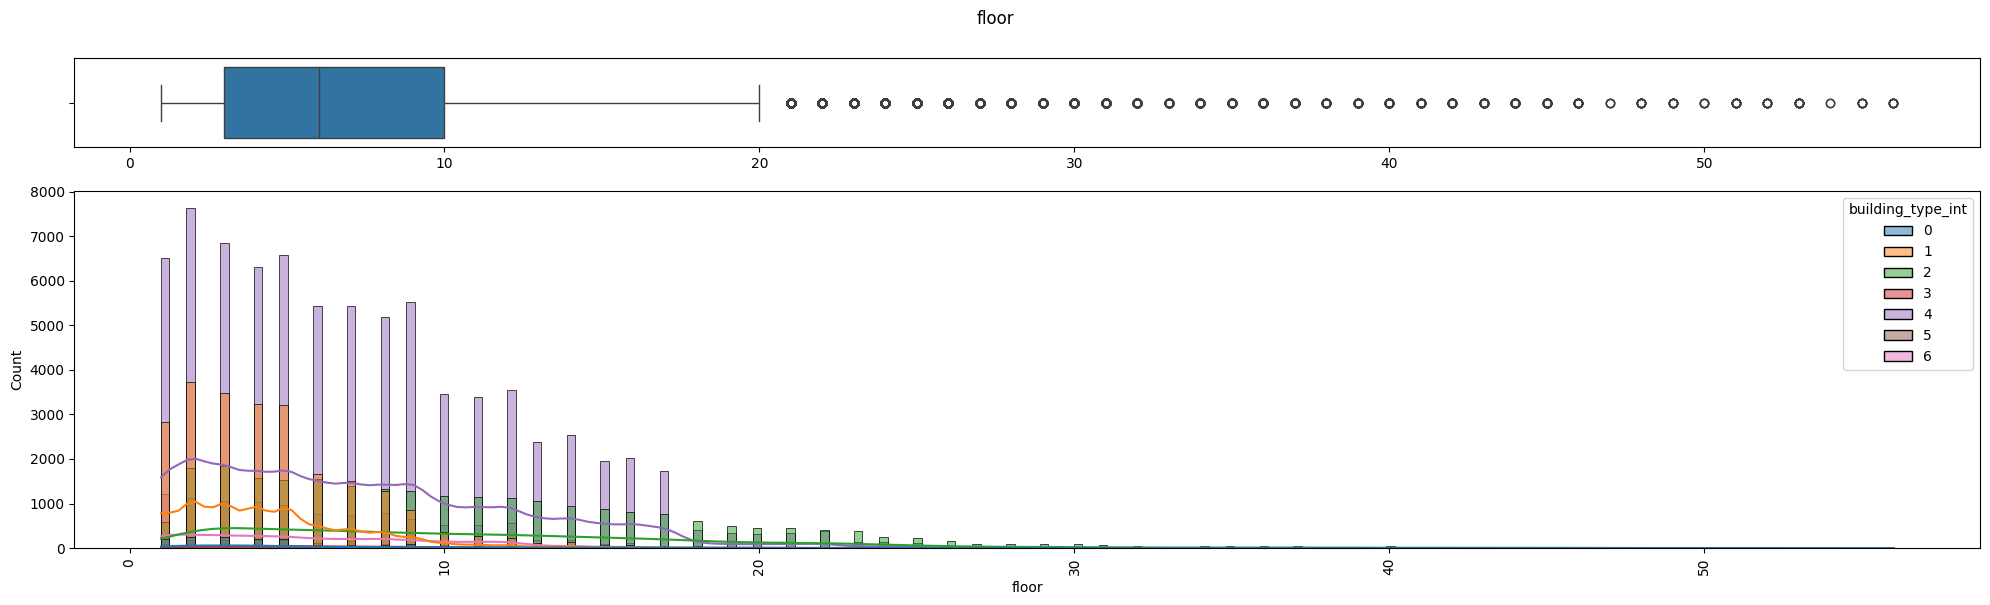

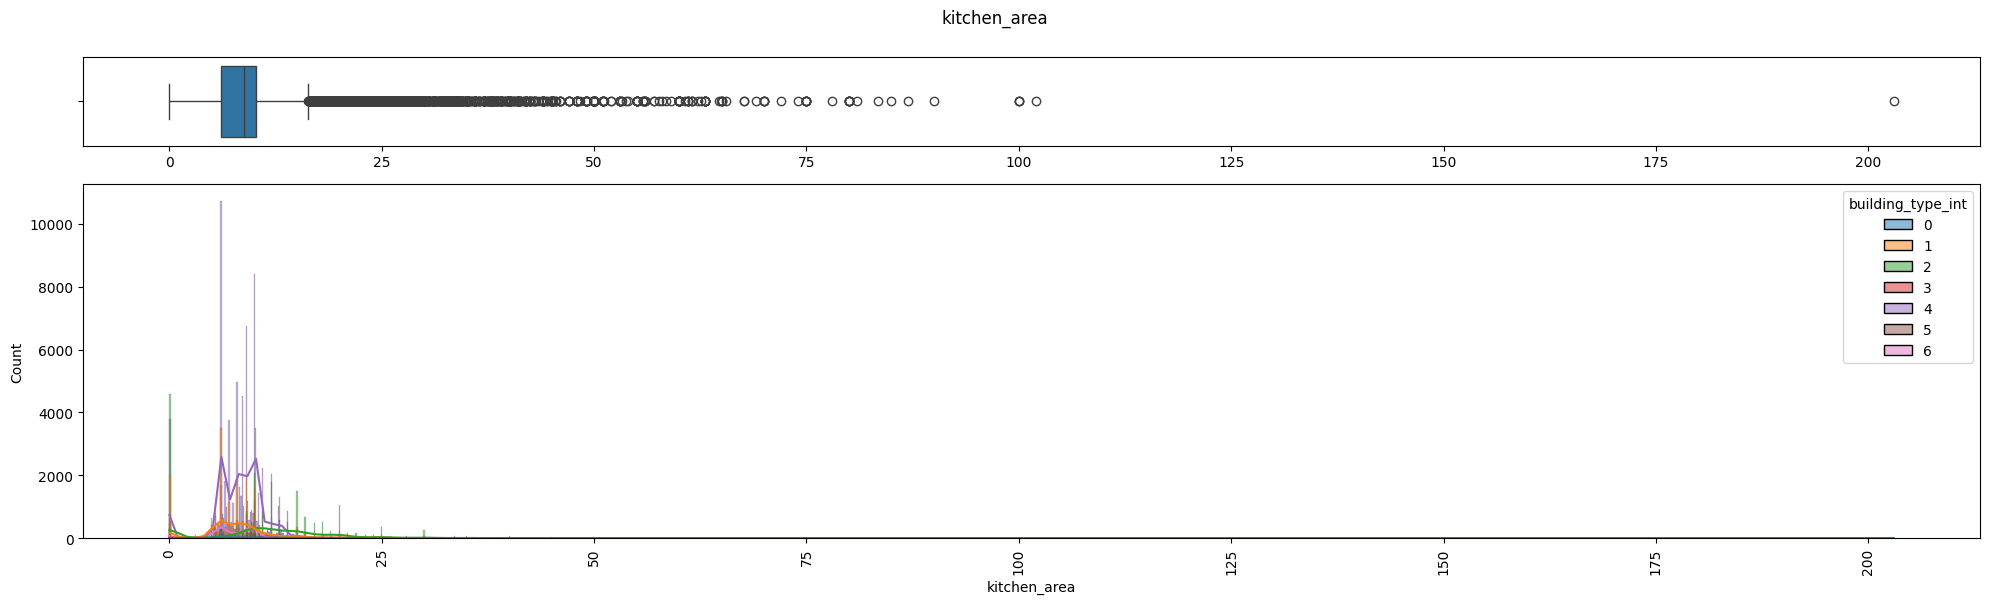

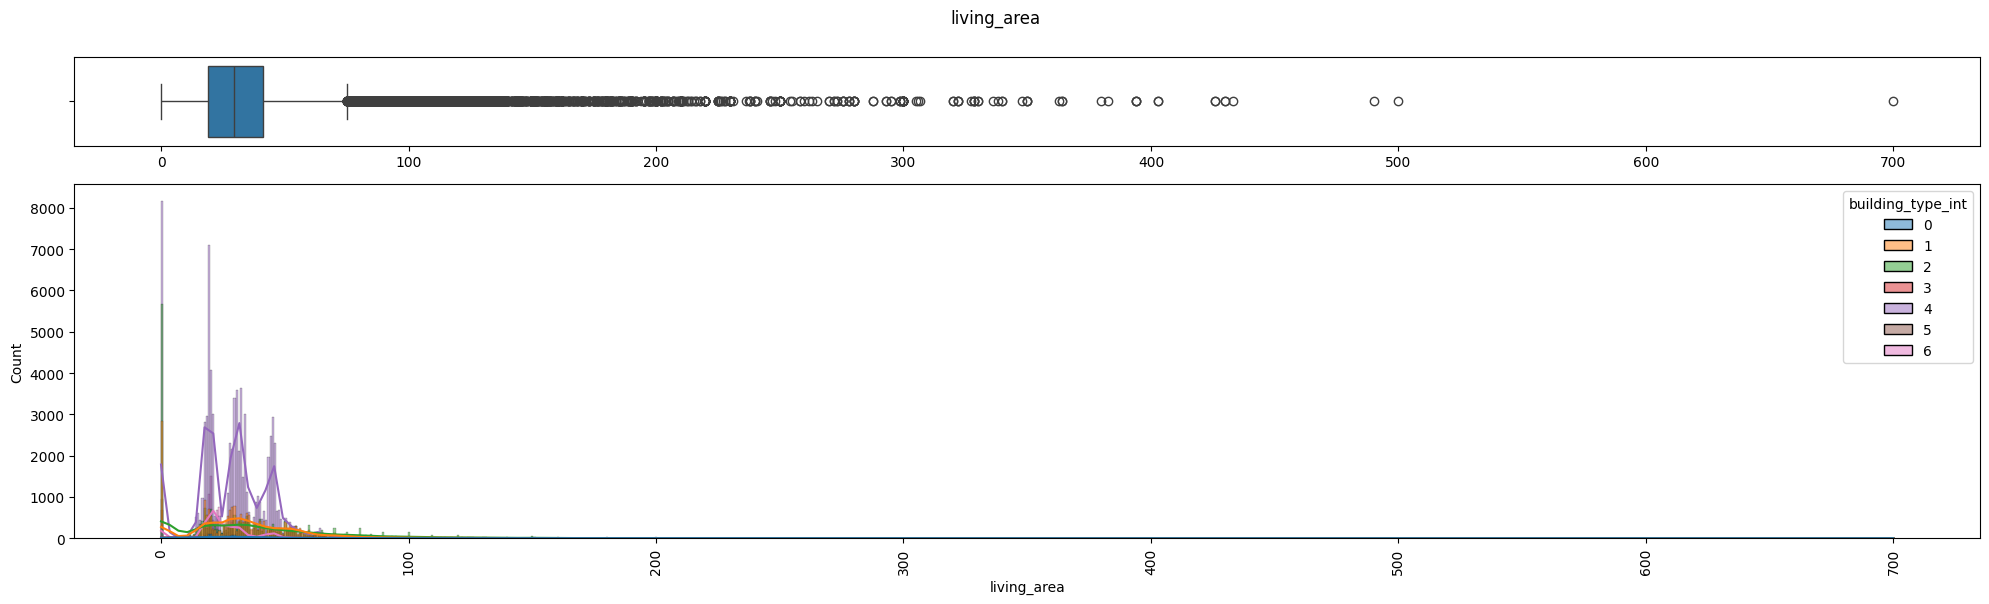

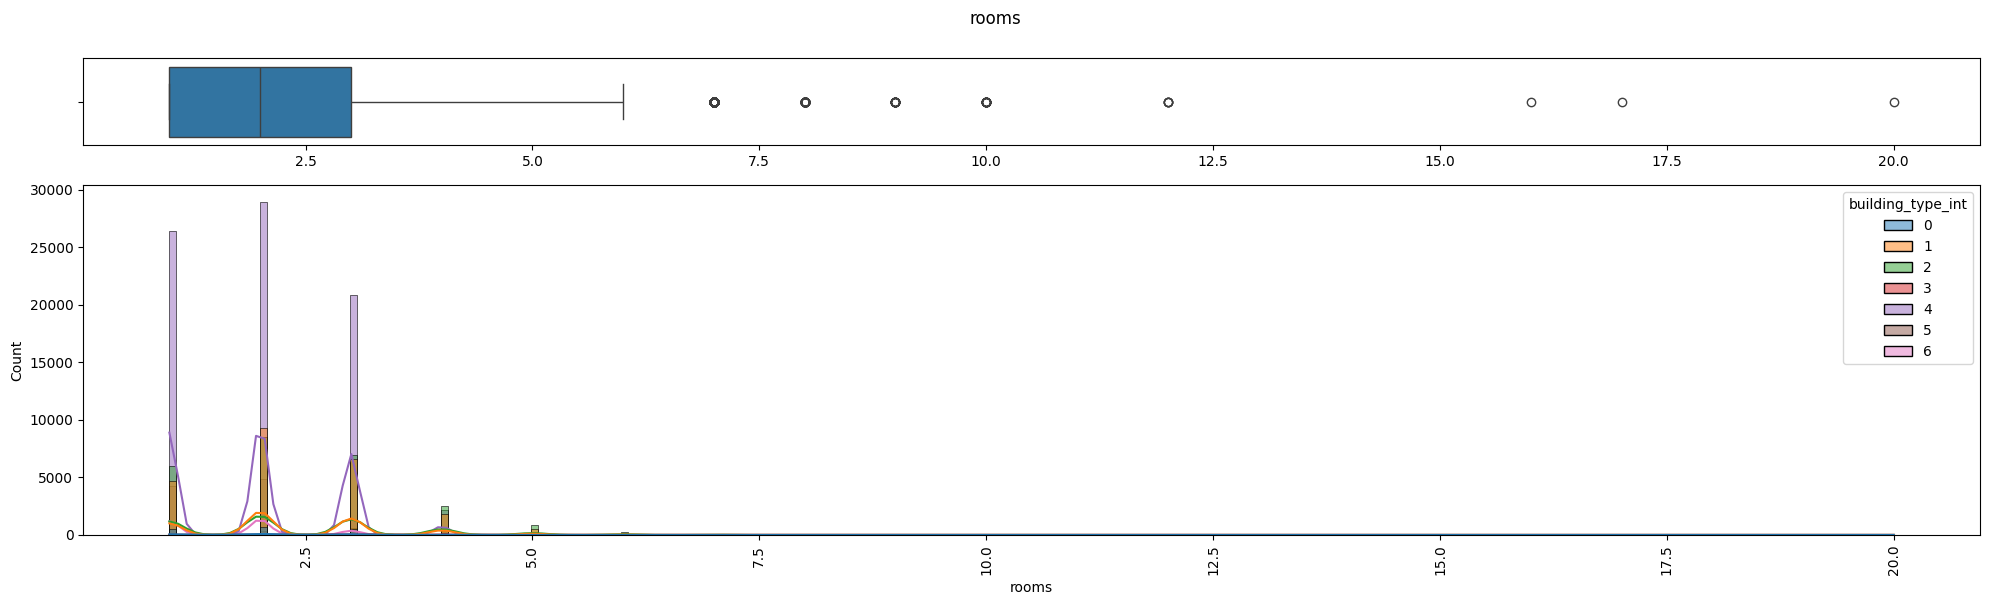

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

for num_col in [target] + num_features:
    fig, axes = plt.subplots(2, 1, figsize=(20, 6),
                              gridspec_kw={'height_ratios': [1, 4]})

    sns.boxplot(data=data, x=num_col, ax=axes[0])
    axes[0].set_xlabel('')

    sns.histplot(data=data, x=num_col, kde=True, hue='building_type_int',
                 palette='tab10', ax=axes[1])
    axes[1].tick_params(axis='x', rotation=90)

    plt.suptitle(f'{num_col}', y=1.0)
    plt.tight_layout()
    plt.show()

Большинство числовых признаков (площади, количество комнат, этажность) имеют ярко выраженную правостороннюю асимметрию. Это означает, что основная масса предложений — это типовое жилье (масс-маркет), а длинный хвост формирует элитная недвижимость. Это не выбросы в статистическом смысле, а представители другого сегмента рынка (премиум-класса). Удаление таких строк лишит модель возможности предсказывать цены на элитное жилье.

<Axes: >

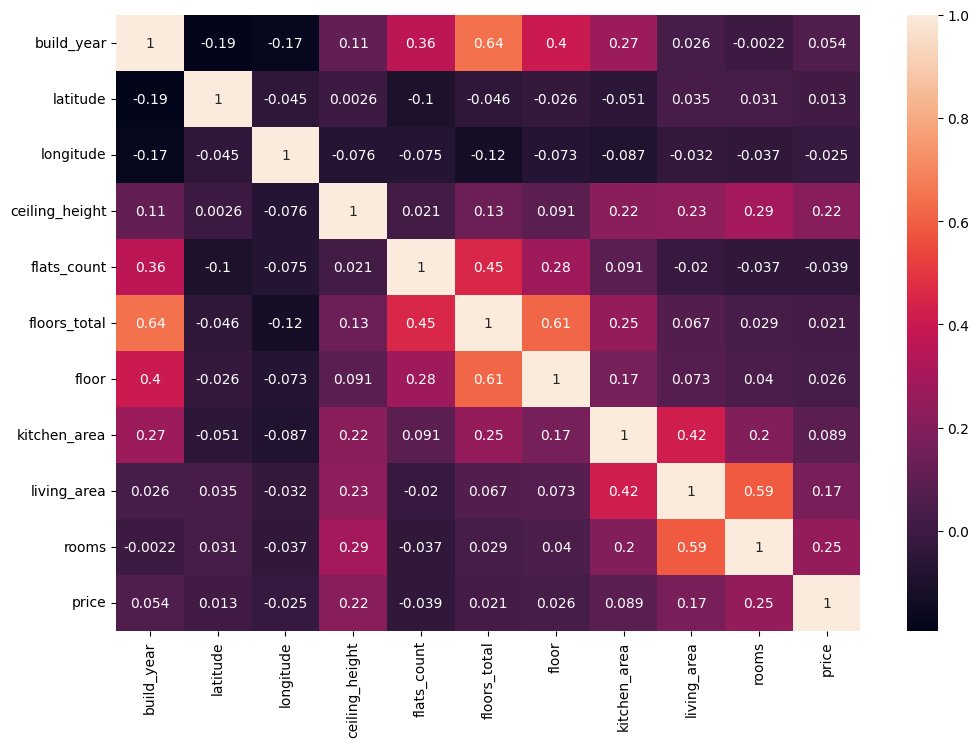

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(data[num_features + [target]].corr(), annot=True)

Главные драйверы стоимости (Сильная прямая связь): Общая площадь (total_area), жилая площадь (living_area), площадь кухни (kitchen_area) и количество комнат (rooms). Это самые сильные предикторы: чем больше площадь, тем выше цена квартиры.

**Функции очистки данных**

In [19]:
def remove_duplicates(data):
    feature_cols = data.columns.drop('flat_id').tolist()
    is_duplicated_features = data.duplicated(subset=feature_cols, keep=False)
    data = data[~is_duplicated_features].reset_index(drop=True)
    return data

def remove_outliers(data):
    """
    Удаляет явно ошибочные значения (физически невозможные),
    но сохраняет реальные элитные и нестандартные объекты.
    Пороги выбраны на основе EDA.
    """
    # Явные ошибки и опечатки
    data = data[data['ceiling_height'].between(2.0, 5.0)]      # реальные потолки
    data = data[data['price'].between(100_000, 1_000_000_000)] # 100К–1млрд ₽
    data = data[data['total_area'].between(10, 500)]           # 10–500 м²
    data = data[data['living_area'] <= 300]                    # до 300 м²
    data = data[data['kitchen_area'] <= 100]                   # до 100 м²
    data = data[data['rooms'] <= 10]                           # до 10 комнат
    data = data[data['floors_total'].between(1, 100)]          # 1–100 этажей
    return data.reset_index(drop=True)

def fill_missing_values(data):
    """
    Пропусков в текущем срезе нет. 
    Функция fill_missing_values оставлена для устойчивости пайплайна — 
    если новые данные содержат пропуски, она их обработает.
    """
    num_features = ['build_year', 'latitude', 'longitude', 'ceiling_height', 'flats_count', 'floors_total', 'floor', 'kitchen_area', 'living_area', 'rooms', 'total_area']
    cat_features = ['building_type_int', 'has_elevator', 'is_apartment', 'studio']
    for col in num_features:
        fill_value = data[col].mean()
        data[col] = data[col].fillna(fill_value)
    for col in cat_features:
        fill_value = data[col].mode().iloc[0]
        data[col] = data[col].fillna(fill_value)
    return data

data = data.drop(columns=['id', 'building_id'])
data = remove_duplicates(data)
data = remove_outliers(data)
data = fill_missing_values(data)

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123661 entries, 0 to 123660
Data columns (total 17 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   flat_id            123661 non-null  int64  
 1   build_year         123661 non-null  int64  
 2   building_type_int  123661 non-null  int64  
 3   latitude           123661 non-null  float64
 4   longitude          123661 non-null  float64
 5   ceiling_height     123661 non-null  float64
 6   flats_count        123661 non-null  int64  
 7   floors_total       123661 non-null  int64  
 8   has_elevator       123661 non-null  int64  
 9   floor              123661 non-null  int64  
 10  kitchen_area       123661 non-null  float64
 11  living_area        123661 non-null  float64
 12  rooms              123661 non-null  int64  
 13  is_apartment       123661 non-null  int64  
 14  studio             123661 non-null  int64  
 15  total_area         123661 non-null  float64
 16  pr

**Проверка таблицы real_estate_clean**

In [20]:
data = pd.read_sql("""
select * from real_estate_clean
""", dst_conn)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123661 entries, 0 to 123660
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 123661 non-null  int64  
 1   flat_id            123661 non-null  int64  
 2   build_year         123661 non-null  int64  
 3   building_type_int  123661 non-null  int64  
 4   latitude           123661 non-null  float64
 5   longitude          123661 non-null  float64
 6   ceiling_height     123661 non-null  float64
 7   flats_count        123661 non-null  int64  
 8   floors_total       123661 non-null  int64  
 9   has_elevator       123661 non-null  int64  
 10  floor              123661 non-null  int64  
 11  kitchen_area       123661 non-null  float64
 12  living_area        123661 non-null  float64
 13  rooms              123661 non-null  int64  
 14  is_apartment       123661 non-null  int64  
 15  studio             123661 non-null  int64  
 16  to

In [21]:
data.describe()

,id,flat_id,build_year,building_type_int,latitude,longitude,ceiling_height,flats_count,floors_total,has_elevator,floor,kitchen_area,living_area,rooms,is_apartment,studio,total_area,price
count,123661.000000,123661.000000,123661.000000,123661.000000,123661.000000,123661.000000,123661.000000,123661.000000,123661.000000,123661.000000,123661.000000,123661.000000,123661.000000,123661.000000,123661.000000,123661.0,123661.000000,1.236610e+05
mean,61831.000000,70552.999895,1986.393350,3.249359,55.730625,37.589440,2.749185,251.263567,14.048981,0.896418,7.444214,8.928382,30.832911,2.115712,0.009413,0.0,61.332647,1.843990e+07
std,35698.000156,40936.276978,21.990198,1.459621,0.103180,0.150762,0.204174,206.561910,6.861134,0.304718,5.689234,5.091377,22.564077,0.973693,0.096562,0.0,36.503000,3.217929e+07
min,1.000000,0.000000,1901.000000,0.000000,55.211460,36.864372,2.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.0,11.000000,1.000000e+05
25%,30916.000000,35071.000000,1969.000000,2.000000,55.653915,37.491810,2.640000,111.000000,9.000000,1.000000,3.000000,6.100000,19.000000,1.000000,0.000000,0.0,39.099998,8.900000e+06
50%,61831.000000,70670.000000,1984.000000,4.000000,55.724865,37.581387,2.640000,199.000000,14.000000,1.000000,6.000000,8.700000,29.400000,2.000000,0.000000,0.0,52.500000,1.180000e+07
75%,92746.000000,106095.000000,2006.000000,4.000000,55.808807,37.693031,2.800000,322.000000,17.000000,1.000000,10.000000,10.200000,41.000000,3.000000,0.000000,0.0,71.000000,1.670000e+07
max,123661.000000,141361.000000,2023.000000,6.000000,56.011032,37.946411,5.000000,4455.000000,99.000000,1.000000,56.000000,100.000000,300.000000,10.000000,1.000000,0.0,500.000000,9.751810e+08
